In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from joblib import Memory

base = next(
    p for r in [Path.cwd(), *Path.cwd().parents]
    for p in [r, r / "PRE_06_clustering_mercadeo"]
    if p.name == "PRE_06_clustering_mercadeo" and (p / "data").is_dir()
)
submission = base / "submission"
submission.mkdir(exist_ok=True)
cache = Memory(base / "temp" / "cache", verbose=0)

data = pd.read_csv(base / "data/snsdata.csv")
data.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,cute,sex,sexy,hot,kissed,dance,band,marching,music,rock,god,church,jesus,bible,hair,dress,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2,2,1,0,0,0,6,4,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2006,NaN,18.995,10,0,0,0,0,0,0,0,0,0,0,0,1,0,0,5,1,1,0,3,0,1,0,0,0,1,0,0,0,2,0,0,0,0,0,1,1


In [2]:
data.shape

(30000, 40)

In [3]:
data.isna().sum()

gradyear           0
gender          2724
age             5086
friends            0
basketball         0
football           0
soccer             0
softball           0
volleyball         0
swimming           0
cheerleading       0
baseball           0
tennis             0
sports             0
cute               0
sex                0
sexy               0
hot                0
kissed             0
dance              0
band               0
marching           0
music              0
rock               0
god                0
church             0
jesus              0
bible              0
hair               0
dress              0
blonde             0
mall               0
shopping           0
clothes            0
hollister          0
abercrombie        0
die                0
death              0
drunk              0
drugs              0
dtype: int64

In [4]:
intereses = data.columns[4:].tolist()
data[intereses].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
basketball,30000.0,0.267333,0.804708,0.0,0.0,0.0,0.0,24.0
football,30000.0,0.252300,0.705357,0.0,0.0,0.0,0.0,15.0
soccer,30000.0,0.222767,0.917226,0.0,0.0,0.0,0.0,27.0
softball,30000.0,0.161200,0.739707,0.0,0.0,0.0,0.0,17.0
volleyball,30000.0,0.143133,0.639943,0.0,0.0,0.0,0.0,14.0
swimming,30000.0,0.134400,0.516990,0.0,0.0,0.0,0.0,31.0
cheerleading,30000.0,0.106633,0.514333,0.0,0.0,0.0,0.0,9.0
baseball,30000.0,0.104933,0.521726,0.0,0.0,0.0,0.0,16.0
tennis,30000.0,0.087333,0.516961,0.0,0.0,0.0,0.0,15.0
sports,30000.0,0.139967,0.471080,0.0,0.0,0.0,0.0,12.0


In [5]:
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

config = {"n_clusters": 5, "n_init": 10, "random_state": 42,
          "features": intereses, "imputacion": "median", "escala": "standard",
          "sklearn": sklearn.__version__}
(submission / "config.json").write_text(json.dumps(config, indent=2))

@cache.cache
def segmentar(datos, config):
    modelo = make_pipeline(
        SimpleImputer(strategy=config["imputacion"]),
        StandardScaler(),
        KMeans(n_clusters=config["n_clusters"], n_init=config["n_init"],
               random_state=config["random_state"]),
    )
    modelo.fit(datos[config["features"]])
    return modelo

modelo = segmentar(data[intereses], config)
segmented = data.copy()
segmented["cluster"] = modelo.named_steps["kmeans"].labels_
segmented.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,cute,sex,sexy,hot,kissed,dance,band,marching,music,rock,god,church,jesus,bible,hair,dress,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs,cluster
0,2006,M,18.982,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
1,2006,F,18.801,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2,2,1,0,0,0,6,4,0,1,0,0,0,0,0,0,0,0,1
2,2006,M,18.335,69,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3
3,2006,F,18.875,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
4,2006,NaN,18.995,10,0,0,0,0,0,0,0,0,0,0,0,1,0,0,5,1,1,0,3,0,1,0,0,0,1,0,0,0,2,0,0,0,0,0,1,1,2


In [6]:
cantidad = segmented["cluster"].value_counts().sort_index()
cantidad

cluster
0      671
1     5412
2     1093
3    22823
4        1
Name: count, dtype: int64

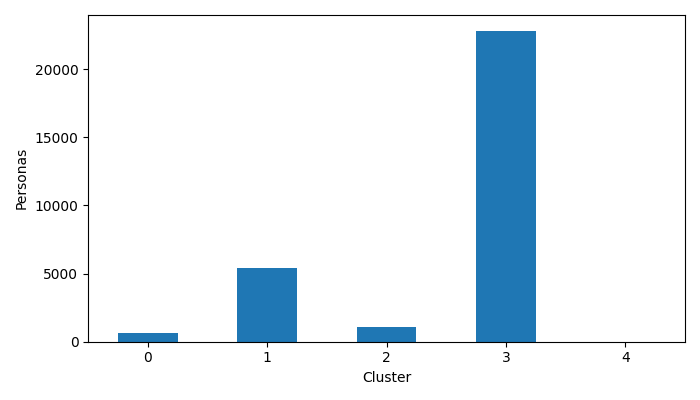

In [7]:
cantidad.plot.bar(figsize=(7, 4), color="tab:blue", rot=0)
plt.xlabel("Cluster")
plt.ylabel("Personas")
plt.tight_layout()
plt.show()

In [8]:
perfiles = pd.DataFrame(
    modelo.named_steps["kmeans"].cluster_centers_, columns=intereses
)
perfiles.index.name = "cluster"
perfiles.round(2)

,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,cute,sex,sexy,hot,kissed,dance,band,marching,music,rock,god,church,jesus,bible,hair,dress,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.12,0.04,0.02,0.02,-0.01,0.08,-0.01,0.05,0.11,-0.02,-0.03,-0.03,-0.10,-0.02,-0.05,-0.00,0.20,0.05,0.25,0.08,2.55,2.26,2.70,3.87,0.05,0.03,-0.00,-0.08,0.02,0.05,-0.09,-0.08,0.24,0.31,0.04,0.02
1,0.49,0.51,0.28,0.39,0.43,0.32,0.44,0.25,0.12,0.30,0.67,-0.00,0.28,0.50,-0.03,0.54,0.05,-0.00,0.23,0.19,0.06,0.24,-0.02,-0.08,0.31,0.43,0.05,0.66,0.89,0.49,0.59,0.55,0.02,0.09,0.00,-0.06
2,0.38,0.38,0.14,0.17,0.10,0.27,0.20,0.29,0.11,0.84,0.47,2.00,0.51,0.31,2.95,0.45,0.61,0.19,1.24,1.24,0.33,0.14,0.05,0.04,2.55,0.55,0.20,0.64,0.29,1.29,0.37,0.45,1.64,0.89,1.74,2.63
3,-0.14,-0.14,-0.07,-0.10,-0.11,-0.09,-0.11,-0.07,-0.04,-0.11,-0.18,-0.10,-0.09,-0.13,-0.13,-0.15,-0.05,-0.01,-0.12,-0.11,-0.11,-0.13,-0.08,-0.10,-0.20,-0.13,-0.03,-0.18,-0.22,-0.18,-0.15,-0.15,-0.09,-0.07,-0.09,-0.11
4,-0.33,2.48,-0.24,-0.22,-0.22,1.67,-0.21,-0.20,-0.17,-0.30,0.84,19.40,1.63,-0.26,-0.20,0.49,0.63,-0.14,-0.59,1.05,7.10,-0.30,1.53,-0.10,10.54,4.20,168.31,-0.37,-0.49,1.80,-0.20,-0.18,9.31,13.48,14.81,-0.17


In [9]:
principales = pd.DataFrame({
    n: perfiles.loc[n].nlargest(5).index.tolist()
    for n in perfiles.index
}).T
principales.columns = [f"Interes {n}" for n in range(1, 6)]
principales.index.name = "cluster"
principales

,Interes 1,Interes 2,Interes 3,Interes 4,Interes 5
cluster,,,,,
0,bible,jesus,god,church,death
1,shopping,cute,mall,hollister,abercrombie
2,kissed,drugs,hair,sex,drunk
3,marching,blonde,tennis,band,death
4,blonde,sex,drunk,death,hair


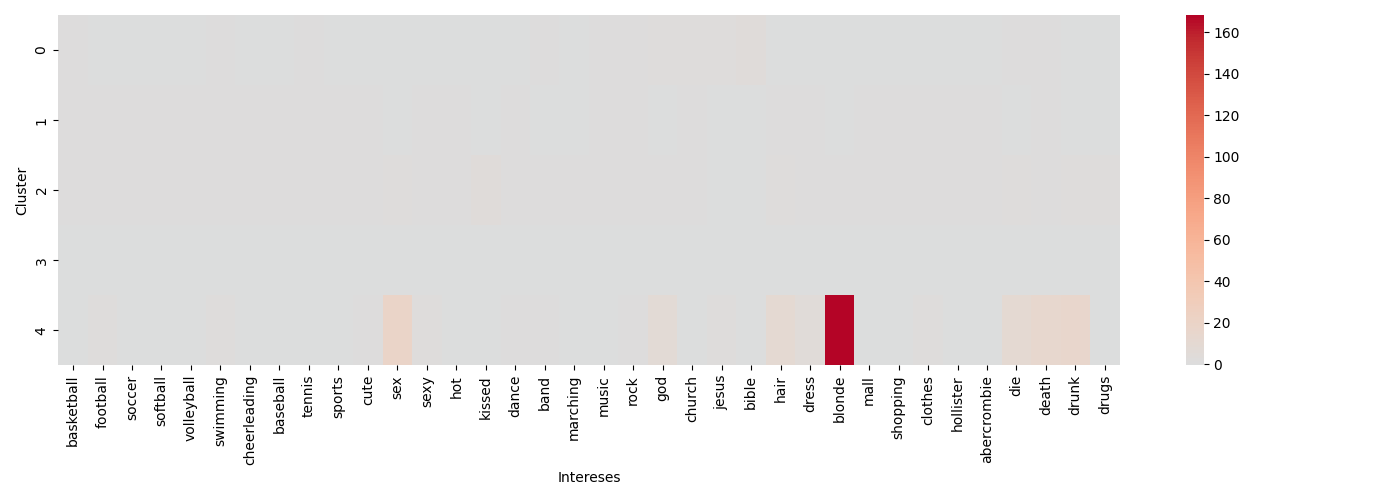

In [10]:
import seaborn as sns

plt.figure(figsize=(14, 5))
sns.heatmap(perfiles, cmap="coolwarm", center=0)
plt.xlabel("Intereses")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [11]:
segmented.to_csv(submission / "segmented.csv")
segmented.groupby("cluster")[["friends"] + intereses].mean().round(2)

,friends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,cute,sex,sexy,hot,kissed,dance,band,marching,music,rock,god,church,jesus,bible,hair,dress,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,35.23,0.36,0.28,0.24,0.17,0.14,0.18,0.10,0.13,0.14,0.14,0.30,0.17,0.09,0.12,0.08,0.42,0.52,0.06,1.05,0.30,3.88,2.14,1.69,0.82,0.48,0.13,0.10,0.20,0.37,0.17,0.04,0.03,0.33,0.25,0.11,0.07
1,38.82,0.66,0.61,0.48,0.45,0.42,0.30,0.33,0.24,0.15,0.28,0.86,0.21,0.29,0.37,0.09,1.06,0.36,0.04,1.03,0.38,0.55,0.44,0.10,0.00,0.77,0.30,0.19,0.71,0.99,0.38,0.27,0.20,0.20,0.15,0.09,0.04
2,30.59,0.57,0.52,0.35,0.28,0.21,0.27,0.21,0.25,0.15,0.53,0.70,2.45,0.41,0.27,1.61,0.95,0.98,0.10,2.29,1.14,0.91,0.36,0.14,0.03,3.23,0.36,0.50,0.70,0.56,0.76,0.20,0.18,1.21,0.50,0.78,0.97
3,27.96,0.16,0.15,0.15,0.09,0.08,0.09,0.05,0.07,0.07,0.09,0.18,0.10,0.10,0.06,0.04,0.25,0.25,0.04,0.58,0.17,0.32,0.14,0.07,0.00,0.20,0.05,0.04,0.13,0.19,0.06,0.02,0.01,0.13,0.08,0.05,0.02
4,44.00,0.00,2.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,22.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,10.00,0.00,1.00,0.00,12.00,2.00,327.00,0.00,0.00,1.00,0.00,0.00,6.00,6.00,6.00,0.00
